# Tutorial: Milestone 2 - Toy Multimodal Fusion

Audience:
- You've completed Milestones 0 and 1 (text-only, on toy and then real data) and understand the
  load -> split -> train -> evaluate loop plus TF-IDF, accuracy, and macro-F1.

Prerequisites:
- Run `python src/generate_toy_multimodal.py` first (from a terminal, in the `mmi` environment) --
  this notebook loads the files it creates under `data/toy_multimodal/`.

Learning goals:
- By the end, you can explain what 'concatenation fusion' means, extract simple features from three
  different modalities, and explain why feature scaling matters when combining them.

**Why synthetic data:** the real MIntRec audio/video lives in an 800MB+ archive we haven't downloaded
yet (out of scope for this increment -- see `docs/superpowers/specs/2026-08-05-milestone2-toy-fusion-design.md`).
Here we generate small FAKE audio/video files whose frequency/color is deliberately tied to each of the
8 intents, so we can prove the fusion *mechanics* work in seconds, offline, with zero new installs.


## Outline

1. Setup
2. Step 1 - Load the toy multimodal index
3. Step 2 - Split into train / validation / test
4. Step 3 - Extract features from each modality and fuse them
5. Step 4 - Evaluate, and compare against the Milestone 0 text-only baseline
6. Look at the mistakes
7. Exercises
8. Pitfalls and extensions


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
INDEX_PATH = PROJECT_ROOT / "data" / "toy_multimodal" / "index.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
SAMPLE_RATE = 8000  # must match src/generate_toy_multimodal.py
INDEX_PATH


WindowsPath('C:/Users/dbest/Downloads/multimodal-intent-inference/multimodal-intent-inference/data/toy_multimodal/index.csv')

## Step 1 - Load the toy multimodal index

`index.csv` (built by `src/generate_toy_multimodal.py`) has one row per sample, pointing at that
sample's fake audio and video files. It doesn't contain the audio/video data itself -- just paths to it,
the same way the real MIntRec dataset's `.tsv` files point at separate video segment files.


In [2]:
df = pd.read_csv(INDEX_PATH)
print(f"Loaded {len(df)} samples from {INDEX_PATH.name}")
df["intent"].value_counts()


Loaded 96 samples from index.csv


intent
greeting     12
thank        12
apologize    12
agree        12
disagree     12
complain     12
request      12
reassure     12
Name: count, dtype: int64

Sample: 'Hey there, good to see you again!' -> intent=greeting
Audio clip shape: (4000,), dtype: float32
Video frame shape: (16, 16, 3), dtype: uint8


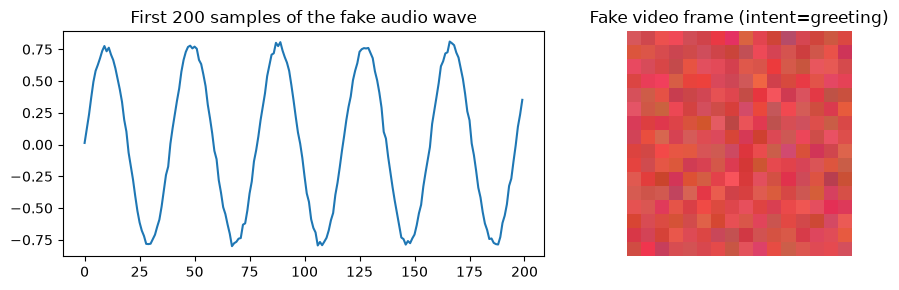

In [3]:
# Peek at one sample's raw audio (a sine wave) and video (a small RGB frame).
sample = df.iloc[0]
clip = np.load(PROJECT_ROOT / sample["audio_path"])
frame = np.load(PROJECT_ROOT / sample["video_path"])
print(f"Sample: {sample['text']!r} -> intent={sample['intent']}")
print(f"Audio clip shape: {clip.shape}, dtype: {clip.dtype}")
print(f"Video frame shape: {frame.shape}, dtype: {frame.dtype}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(clip[:200])
axes[0].set_title("First 200 samples of the fake audio wave")
axes[1].imshow(frame)
axes[1].set_title(f"Fake video frame (intent={sample['intent']})")
axes[1].axis("off")
fig.tight_layout()
plt.show()


## Step 2 - Split into train / validation / test

Identical split logic (same `test_size`, `random_state`, `stratify`) to Milestones 0 and 1, so results
stay comparable across notebooks.


In [4]:
train_val, test = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["intent"]
)
train, val = train_test_split(
    train_val, test_size=0.1875, random_state=42, stratify=train_val["intent"]
)

print(f"train: {len(train)} samples")
print(f"val:   {len(val)} samples")
print(f"test:  {len(test)} samples")


train: 61 samples
val:   15 samples
test:  20 samples


## Step 3 - Extract features from each modality and fuse them

- **Text**: same `TfidfVectorizer` as Milestone 0.
- **Audio**: FFT (Fast Fourier Transform) recovers which pitch is loudest in each fake clip --
  its *dominant frequency* -- plus its RMS *energy* (how loud it is overall). 2 numbers per sample.
- **Video**: mean red/green/blue plus how much the brightness varies across the frame. 4 numbers per sample.

**Concatenation fusion** just means gluing these three feature vectors end to end into one longer vector
per sample, before the classifier ever sees them.


In [5]:
def extract_audio_features(clip):
    fft_vals = np.fft.rfft(clip)
    fft_freqs = np.fft.rfftfreq(len(clip), d=1 / SAMPLE_RATE)
    dominant_freq = fft_freqs[np.argmax(np.abs(fft_vals))]
    energy = np.sqrt(np.mean(clip ** 2))
    return np.array([dominant_freq, energy])


def extract_video_features(frame):
    frame = frame.astype(np.float32)
    mean_r, mean_g, mean_b = frame[..., 0].mean(), frame[..., 1].mean(), frame[..., 2].mean()
    brightness_variance = frame.mean(axis=2).var()
    return np.array([mean_r, mean_g, mean_b, brightness_variance])


def build_audio_features(frame_df):
    return np.array([extract_audio_features(np.load(PROJECT_ROOT / p)) for p in frame_df["audio_path"]])


def build_video_features(frame_df):
    return np.array([extract_video_features(np.load(PROJECT_ROOT / p)) for p in frame_df["video_path"]])


In [6]:
# See the raw feature scales BEFORE scaling -- audio/video numbers are much bigger than TF-IDF.
sample_audio = build_audio_features(train.iloc[:5])
sample_video = build_video_features(train.iloc[:5])
print("Raw audio features (dominant_freq, energy), first 5 rows:")
print(sample_audio)
print("\nRaw video features (R, G, B, brightness_var), first 5 rows:")
print(sample_video)
print("\nNotice: audio frequency is in the hundreds, RGB is 0-255, but TF-IDF values are 0-1ish.")
print("StandardScaler (below) puts every feature on equal footing -- usually the right default.")
print("But 'equal footing' isn't automatically 'better': see the ablation later in this notebook")
print("for what actually happens on THIS data when we equalize a strong signal against a noisy one.")


Raw audio features (dominant_freq, energy), first 5 rows:
[[3.02000000e+02 6.55406475e-01]
 [1.98000000e+02 6.89322889e-01]
 [2.12000000e+02 6.57192886e-01]
 [6.10000000e+02 5.17797172e-01]
 [9.10000000e+02 7.01440632e-01]]

Raw video features (R, G, B, brightness_var), first 5 rows:
[[216.08203  179.91016   74.97266   41.595787]
 [216.39062   76.83594   76.671875  48.9815  ]
 [217.0039    76.64453   75.40625   57.9172  ]
 [ 75.390625 215.29297  215.76172   46.420677]
 [216.71094   75.42578  180.29688   52.288563]]

Notice: audio frequency is in the hundreds, RGB is 0-255, but TF-IDF values are 0-1ish.
StandardScaler (below) puts every feature on equal footing -- usually the right default.
But 'equal footing' isn't automatically 'better': see the ablation later in this notebook
for what actually happens on THIS data when we equalize a strong signal against a noisy one.


In [7]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
text_feats_train = tfidf.fit_transform(train["text"]).toarray()
audio_feats_train = build_audio_features(train)
video_feats_train = build_video_features(train)

fused_train_raw = np.hstack([text_feats_train, audio_feats_train, video_feats_train])
print(f"Fused feature vector size: {fused_train_raw.shape[1]} "
      f"(text={text_feats_train.shape[1]}, audio=2, video=4)")

scaler = StandardScaler()
fused_train = scaler.fit_transform(fused_train_raw)

clf = LogisticRegression(max_iter=1000)
clf.fit(fused_train, train["intent"])
print("Training done.")


Fused feature vector size: 488 (text=482, audio=2, video=4)
Training done.


## Step 4 - Evaluate, and compare against Milestone 0


In [8]:
def transform_features(frame_df):
    text_feats = tfidf.transform(frame_df["text"]).toarray()
    audio_feats = build_audio_features(frame_df)
    video_feats = build_video_features(frame_df)
    fused = np.hstack([text_feats, audio_feats, video_feats])
    return scaler.transform(fused)


fused_test = transform_features(test)
preds = clf.predict(fused_test)
truth = test["intent"].tolist()

acc = accuracy_score(truth, preds)
macro_f1 = f1_score(truth, preds, average="macro")
print(f"Accuracy : {acc:.3f}")
print(f"Macro-F1 : {macro_f1:.3f}")


Accuracy : 0.700
Macro-F1 : 0.683


In [9]:
print(classification_report(truth, preds, zero_division=0))


              precision    recall  f1-score   support

       agree       0.00      0.00      0.00         2
   apologize       1.00      0.50      0.67         2
    complain       1.00      1.00      1.00         3
    disagree       0.40      0.67      0.50         3
    greeting       1.00      1.00      1.00         3
    reassure       1.00      1.00      1.00         2
     request       1.00      0.67      0.80         3
       thank       0.50      0.50      0.50         2

    accuracy                           0.70        20
   macro avg       0.74      0.67      0.68        20
weighted avg       0.76      0.70      0.71        20



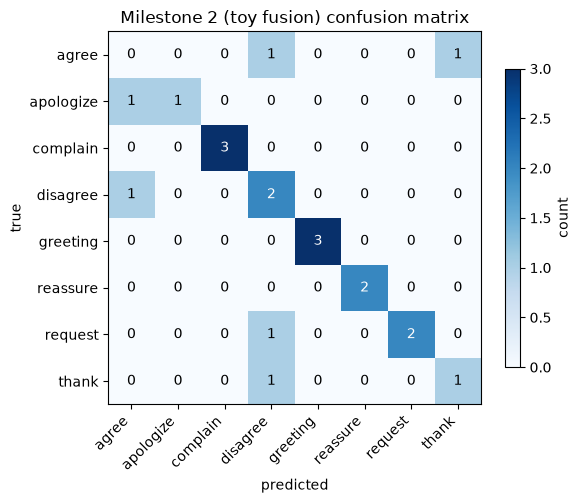

In [10]:
labels = sorted(test["intent"].unique())
cm = confusion_matrix(truth, preds, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Milestone 2 (toy fusion) confusion matrix")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="count")
fig.tight_layout()
plt.show()


### Compare against the Milestone 0 text-only baseline


In [11]:
comparison = pd.DataFrame([
    {"model": "Text-only (M0)", "accuracy": 0.550, "macro_f1": 0.521},
    {"model": "Text+audio+video fusion (M2, toy data)", "accuracy": acc, "macro_f1": macro_f1},
]).set_index("model")
comparison


,accuracy,macro_f1
model,,
Text-only (M0),0.55,0.521000
"Text+audio+video fusion (M2, toy data)",0.70,0.683333


**Interpretation:** because the fake audio and video signals were deliberately tied to the intent
labels, fusion should meet or beat the text-only baseline here. If it doesn't, that's a signal something
is off in the feature extraction or scaling -- worth debugging before trusting this pattern on real data.
Remember: this result says nothing yet about how well fusion will work on REAL audio/video, where the
signal is far messier than a clean sine wave -- it only proves the fusion *mechanics* are correct.


In [12]:
# Ablation: does scaling actually help, or does one modality already nail this on its own?
text_feats_test = tfidf.transform(test["text"]).toarray()
audio_feats_test = build_audio_features(test)
video_feats_test = build_video_features(test)
fused_test_raw = np.hstack([text_feats_test, audio_feats_test, video_feats_test])
text_scaler = StandardScaler().fit(text_feats_train)

def fit_eval(X_train, X_test):
    preds_ = LogisticRegression(max_iter=1000).fit(X_train, train["intent"]).predict(X_test)
    return accuracy_score(truth, preds_), f1_score(truth, preds_, average="macro")

configs = {
    "text-only, no scaler": (text_feats_train, text_feats_test),
    "text-only, with scaler": (text_scaler.transform(text_feats_train), text_scaler.transform(text_feats_test)),
    "video-only": (video_feats_train, video_feats_test),
    "fused, no scaler": (fused_train_raw, fused_test_raw),
    "fused, with scaler (what ships)": (fused_train, fused_test),
}
ablation = pd.DataFrame([
    {"config": name, "accuracy": fit_eval(a, b)[0], "macro_f1": fit_eval(a, b)[1]}
    for name, (a, b) in configs.items()
]).set_index("config")
ablation


,accuracy,macro_f1
config,,
"text-only, no scaler",0.55,0.521429
"text-only, with scaler",0.65,0.615476
video-only,1.00,1.000000
"fused, no scaler",1.00,1.000000
"fused, with scaler (what ships)",0.70,0.683333


**Honest interpretation:** scaling is normally the right call -- you don't usually know in advance
which modality is most informative, and without it, whichever modality happens to have the largest raw
numbers can dominate for no good reason. But the table above shows it isn't free: on this synthetic
dataset, video alone is already an almost perfect predictor, and the fused model *without* scaling
matches that. Scaling spreads the classifier's attention evenly across those few strong audio/video
numbers and the hundreds of noisier text dimensions, which dilutes the strong signal instead of
protecting a weak one -- so the scaled fused model (what actually ships) does worse here than either
video alone or the unscaled fusion. This is exactly why "does fusion actually help?" always deserves an
ablation like the one above, not just a single before/after accuracy number.


## Look at the mistakes


In [13]:
results_df = pd.DataFrame({"text": test["text"], "true": truth, "predicted": preds})

RESULTS_DIR.mkdir(exist_ok=True)
out_path = RESULTS_DIR / "toy_multimodal_predictions.csv"
results_df.to_csv(out_path, index=False)
print(f"Saved every test prediction to {out_path.relative_to(PROJECT_ROOT)}")

mistakes = results_df[results_df["true"] != results_df["predicted"]]
print(f"\n{len(mistakes)} of {len(results_df)} test sentences were misclassified:")
mistakes


Saved every test prediction to results\toy_multimodal_predictions.csv

6 of 20 test sentences were misclassified:


,text,true,predicted
42,"Agreed, let's go with your idea.",agree,thank
81,I'd like you to double-check the numbers.,request,disagree
28,"That's on me, I'm sorry.",apologize,agree
16,"Cheers, you really saved me there.",thank,disagree
45,"Fair enough, I'll go along with it.",agree,disagree
52,That doesn't sound right to me.,disagree,agree


## Exercises

1. **Before scrolling back up:** the ablation table above already shows what happens without
   `StandardScaler` on this data. Without looking, write down in your own words *why* you'd expect
   removing the scaler to help, hurt, or do nothing here -- then scroll up and check your reasoning
   against the actual numbers. Were you right? Now think about a real audio/video dataset (not this
   synthetic one): why might scaling behave differently there, where no single modality is likely to
   be a near-perfect, low-noise predictor the way our fake video is?
2. In `src/generate_toy_multimodal.py`, `BASE_FREQUENCIES` spaces each intent 100Hz apart. Try making
   them all much closer together (e.g. 10Hz apart) by editing that dict, rerun the generator and this
   notebook, and see how much harder that makes the audio signal to use.


## Pitfalls and extensions

**Common mistake (usually):** concatenating features with wildly different scales (frequency in the
hundreds vs. TF-IDF values near 0-1) without scaling first. The model can end up dominated by whichever
modality happens to produce the largest raw numbers -- not whichever modality is actually most
informative. `StandardScaler` (fit on train, applied to val/test) fixes this by putting every feature
on the same footing before the classifier sees it, which is the sane default when you don't know in
advance which modality carries the most signal.

**But not free, as the ablation above shows:** on this particular toy dataset, the 6 audio/video
numbers happen to carry a near-perfect signal (video alone scores ~1.0 accuracy), while the ~480 TF-IDF
text dimensions are much noisier. "Equal footing" here means diluting that strong, low-dimensional
signal by averaging it in with a lot of weak, high-dimensional noise -- so scaling actually *lowers*
accuracy on this data versus leaving it unscaled. We still scale by default (real data won't hand you
such a clean, cheap winner), but the lesson is: don't assume scaling helps fusion -- run the ablation.

**Extension (next increment):** this notebook's 'encoders' are hand-written classic-signal functions,
not learned models -- deliberately, to avoid any downloads here. The real next step is swapping
`extract_audio_features`/`extract_video_features` for real frozen pretrained encoders (e.g. wav2vec2 for
audio, a pretrained CNN for video) once real MIntRec audio/video data is acquired -- a separate,
larger increment that needs its own download-size confirmation.
